# UPI Fraud Detection — Preprocessing


In [1]:
import sys
sys.path.append("../src")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from data.preprocess import (
    load_raw, basic_clean, build_preprocessor, get_feature_names,
    NUMERIC_COLS, CATEGORICAL_COLS, FLAG_COLS
)
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
RANDOM_SEED = 42

## 1. Load & Check Missing Values

In [2]:
df = load_raw("../data/raw/upi_transactions.csv")
print("Shape:", df.shape)
print("\nMissing values per column:")
df.isnull().sum()

Shape: (150000, 14)

Missing values per column:


transaction_id            0
sender_account_name       0
receiver_account_name     0
sender_bank               0
receiver_bank             0
transaction_amount        0
timestamp                 0
transaction_location      0
device_type               0
is_new_beneficiary        0
location_mismatch_flag    0
device_change_flag        0
transactions_last_24h     0
transaction_status        0
dtype: int64

## 2. Clean, Drop Identifiers, Engineer Basic Time Features

In [3]:
X, y = basic_clean(df)
print("Features shape:", X.shape)
print("Target fraud rate:", y.mean().round(4))
X.head()

Features shape: (150000, 11)
Target fraud rate: 0.0795


,sender_bank,receiver_bank,transaction_location,device_type,is_new_beneficiary,location_mismatch_flag,device_change_flag,transactions_last_24h,hour,day_of_week,transaction_amount_log
0,HDFC,Axis,Jaipur,Web,0,0,0,3,11,Monday,7.225751
1,HDFC,Canara,Rural-UP,Android,1,0,0,6,0,Monday,10.126965
2,Union Bank,Axis,Hyderabad,iOS,0,0,0,1,17,Thursday,6.940503
3,Canara,IDFC First,Rural-MP,iOS,0,0,0,1,6,Sunday,7.739873
4,BOB,PNB,Rural-MP,Web,1,0,1,9,1,Friday,10.708904


## 3. Train/Test Split — Before Balancing


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_SEED
)
print("Train:", X_train.shape, "fraud rate:", y_train.mean().round(4))
print("Test: ", X_test.shape, "fraud rate:", y_test.mean().round(4))

Train: (120000, 11) fraud rate: 0.0795
Test:  (30000, 11) fraud rate: 0.0795


## 4. Encode Categoricals + Scale Numerics

In [5]:
preprocessor = build_preprocessor()
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)
feature_names = get_feature_names(preprocessor)

print("Transformed train shape:", X_train_proc.shape)
print("Total engineered feature count:", len(feature_names))
print("\nSample feature names:", feature_names[:10])

Transformed train shape: (120000, 52)
Total engineered feature count: 52

Sample feature names: ['num__transaction_amount_log', 'num__hour', 'num__transactions_last_24h', 'cat__sender_bank_Axis', 'cat__sender_bank_BOB', 'cat__sender_bank_Canara', 'cat__sender_bank_HDFC', 'cat__sender_bank_ICICI', 'cat__sender_bank_IDFC First', 'cat__sender_bank_Kotak']


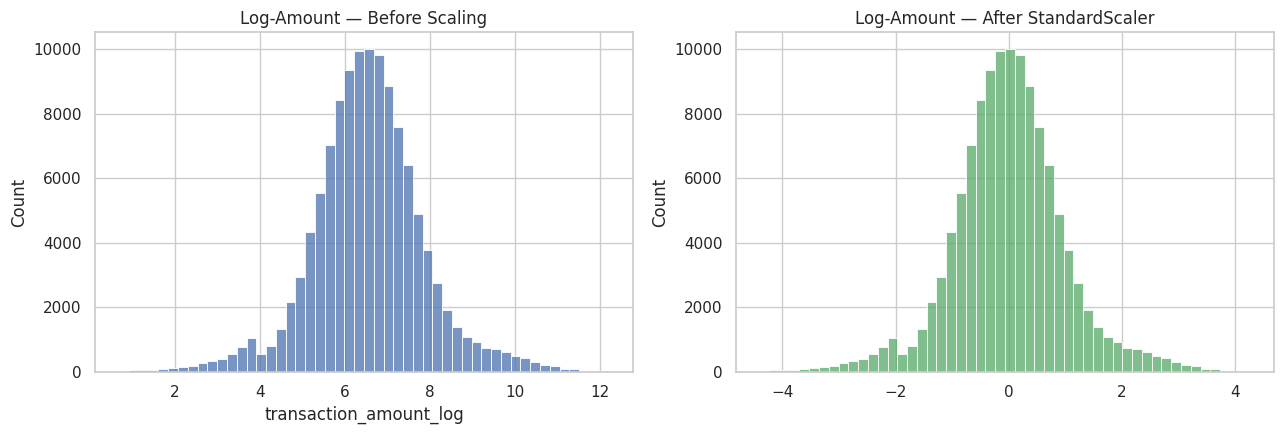

In [6]:
# Preview: numeric features before vs after scaling
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.histplot(X_train["transaction_amount_log"], bins=50, ax=axes[0], color="#4C72B0")
axes[0].set_title("Log-Amount — Before Scaling")

scaled_amount_idx = feature_names.index("num__transaction_amount_log")
sns.histplot(X_train_proc[:, scaled_amount_idx], bins=50, ax=axes[1], color="#55A868")
axes[1].set_title("Log-Amount — After StandardScaler")

plt.tight_layout()
plt.savefig("../reports/figures/10_scaling_before_after.png", dpi=150)
plt.show()

## 5. Balance the Training Set with SMOTE


In [7]:
smote = SMOTE(random_state=RANDOM_SEED)
X_train_bal, y_train_bal = smote.fit_resample(X_train_proc, y_train)

print("Before SMOTE:", X_train_proc.shape, "fraud rate:", y_train.mean().round(4))
print("After SMOTE: ", X_train_bal.shape, "fraud rate:", y_train_bal.mean().round(4))

Before SMOTE: (120000, 52) fraud rate: 0.0795
After SMOTE:  (220930, 52) fraud rate: 0.5


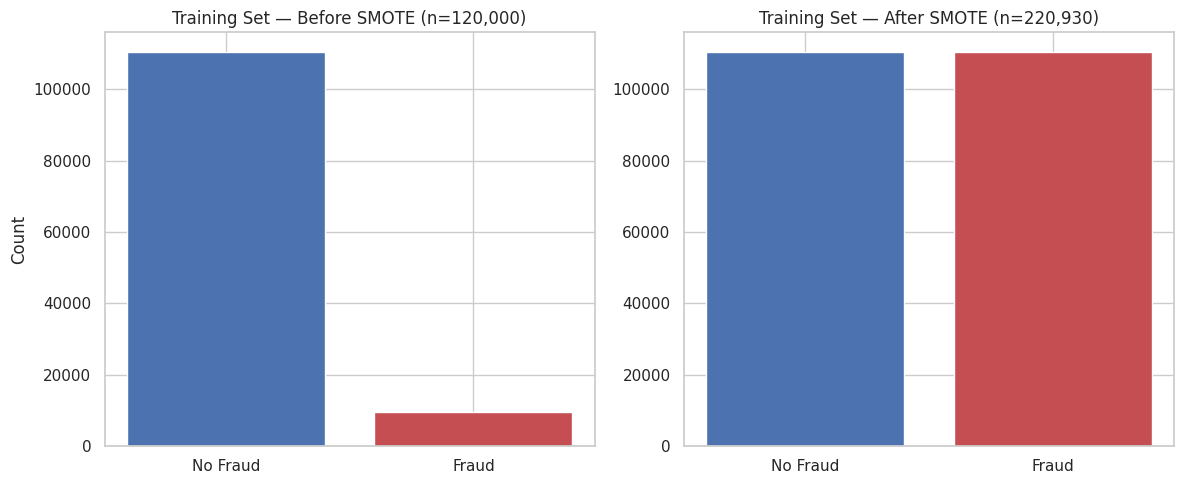

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

before_counts = y_train.value_counts().sort_index()
after_counts = pd.Series(y_train_bal).value_counts().sort_index()

axes[0].bar(["No Fraud", "Fraud"], before_counts.values, color=["#4C72B0", "#C44E52"])
axes[0].set_title(f"Training Set — Before SMOTE (n={len(y_train):,})")
axes[0].set_ylabel("Count")

axes[1].bar(["No Fraud", "Fraud"], after_counts.values, color=["#4C72B0", "#C44E52"])
axes[1].set_title(f"Training Set — After SMOTE (n={len(y_train_bal):,})")

plt.tight_layout()
plt.savefig("../reports/figures/11_smote_before_after.png", dpi=150)
plt.show()

## 6. Save Processed Data & Preprocessing Artifact

In [9]:
import os
os.makedirs("../data/processed", exist_ok=True)
os.makedirs("../models", exist_ok=True)

pd.DataFrame(X_train_bal, columns=feature_names).to_csv("../data/processed/X_train_balanced.csv", index=False)
pd.Series(y_train_bal, name="is_fraud").to_csv("../data/processed/y_train_balanced.csv", index=False)
pd.DataFrame(X_test_proc, columns=feature_names).to_csv("../data/processed/X_test.csv", index=False)
pd.Series(y_test.values, name="is_fraud").to_csv("../data/processed/y_test.csv", index=False)

import joblib
joblib.dump(preprocessor, "../models/preprocessor.pkl")

print("Saved processed train/test sets to data/processed/")
print("Saved fitted preprocessor to models/preprocessor.pkl")

Saved processed train/test sets to data/processed/
Saved fitted preprocessor to models/preprocessor.pkl
